# UNIMODAL: clinical close-up

# Notebok for training the models. They are saved and later loaded in another notebook for tests.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

WORK_DIR_ROOT = '/content/drive/MyDrive/datasets/Master/'
sys.path.append(WORK_DIR_ROOT)

from utils import *



DATASET_ROOT = '/content/drive/MyDrive/datasets/Master/datasets_orig'
METADATA_TRAIN_PATH = f"{DATASET_ROOT}/MILK10k_Training_Metadata.csv"
METADATA_TEST_PATH = f"{DATASET_ROOT}/MILK10k_Test_Metadata.csv"
#DATASET_TRAIN_ZIP = f"{DATASET_ROOT}/MILK10k_Training_Input.zip"
#DATASET_TRAIN = f"{DATASET_ROOT}/MILK10k_Training_Input/MILK10k_Training_Input/"
DATASET_RESIZED = f"{WORK_DIR_ROOT}/mal_ben_datasets_resized_stratified/"
GT_PATH = f"{DATASET_ROOT}/MILK10k_Training_GroundTruth.csv"


CHECKPOINT_DIR = WORK_DIR_ROOT + 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive


## 1. Load the train and validation datasets, applying transforms, using a custom Dataset class and the stored mao for indices of labels.

### 1.1 Load the custom LABEL_TO_INDEX, and the lessionIds corresponding to Train and Validation.

#### 1.1.1 Prepare a minimal metadata for training and validation by appending the label indices (as saved), and removing the excesive columns

In [2]:
from utils import LABEL_COLUMNS, BENIGNANT_NAMES, MALIGNANT_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

def decode_label_id(row):
    for col in LABEL_COLUMNS:
        if row[col] == 1:
          # check if it is bening or malign:
          if col in BENIGNANT_NAMES:
            return 0
          if col in MALIGNANT_NAMES:
            return 1
    return "UNKNOWN"

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

df_train_clinical_minimal.head()

,lesion_id,isic_id,image_type,label_id
0,IL_0000652,ISIC_8149219,clinical: close-up,1
1,IL_0003176,ISIC_3904045,clinical: close-up,1
2,IL_0004688,ISIC_0791494,clinical: close-up,1
3,IL_0005081,ISIC_5667730,clinical: close-up,1
4,IL_0006177,ISIC_8803389,clinical: close-up,1


#### 1.1.2 Load the lession_ids for train/val/test stratified datasets

In [3]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/b_m_milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# Train
df_train_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)



Lesions - Train: 4192, Val: 524, Test: 524


## 1.2 Create data loaders with a custom dataset class

For this purpose, use a custom Dataset called Milk10kDataset_unimodal, which receives a dataframe to read the metadata and labels from, a root directory to read the image files from, a custom transform to apply to the images. It assumes only one image type, so we filter beforehand.

The class is in a separate python file, since there is some issue with using workers in the dataloader if the class is defined in a notebook cell.

We use the custom PyTorch Dataset to load images on demand from the dataset directory based on metadata provided in a dataframe. During training, images are processed using an online data augmentation pipeline implemented via torchvision transforms. Deterministic preprocessing operations (tensor conversion) are combined with stochastic augmentation (TrivialAugmentWide), which applies a randomly sampled transformation each time an image is accessed. As a result, each training epoch iterates once over the full dataset while exposing the model to different augmented versions of the same images across epochs, without increasing the dataset size or storing augmented samples on disk. This way we ensure a more efficient processing and less overfitting.

For validation and testing, only deterministic preprocessing is applied, ensuring a consistent and unbiased evaluation. Data loading is handled via PyTorch DataLoaders, which sample augmented images dynamically at runtime, for improved generalization while maintaining a fixed dataset cardinality.

We use the lesion_id and isic_id to find the next image. We previously resized all images to 224x224. And for the first experiments we load the clinical: close-up images.

#### 1.2.1 Create the data transformers

In [4]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

#### 1.2.2 Create the data loaders

In [5]:
from utils import Milk10kDataset_unimodal
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_dataset = Milk10kDataset_unimodal(df_train_clinical,
                                        DATASET_RESIZED + "/train",
                                        transform=train_transform)

val_dataset   = Milk10kDataset_unimodal(df_val_clinical,
                                        DATASET_RESIZED + "/validation",
                                        transform=validation_transform)

NUM_WORKERS = os.cpu_count()

# Right now I do grid search for batch size too.


# train_loader = DataLoader(
#     train_dataset,
#     batch_size=32,
#     shuffle=True,
#     num_workers=NUM_WORKERS,
#     pin_memory=True
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=32,
#     shuffle=False,
#     num_workers=NUM_WORKERS,
#     pin_memory=True
# )

# train_loader, val_loader

Using device: cuda


In [7]:
# img, label = next(iter(train_loader))

# Note that batch size will now be 1.
# print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
# print(f"Label shape: {label.shape}")

## 1 Model train (Backbone ResNet50, 2-stage training: head and full)

2-staged, train custom head with backbone frozen, then unfreaze and train the whole model.

Use smaller learning rate for the second stage training.

### 1.1 Define methods
In a separate pythin class so they're accessable in the test notebook too.

In [6]:
from ResNet50_1_definitions import *

### 1.2 Use optuna for prameter search (learning rates)


In [6]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 23.1 MB/s eta 0:00:00


In [9]:
import optuna
import torch.nn as nn

def objective(trial):
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Rebuild dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    model = ResNet50Classifier(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()

    # STAGE 1: HEAD ONLY
    freeze_backbone(model)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=8,   # short for Optuna
        patience=3,
        save_path=None
    )

    # STAGE 2: FULL MODEL
    unfreeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=8,   # also short
        patience=3,
        save_path=None
    )

    # Final evaluation
    _, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    return val_acc

############# Run the study:
if True:
  study = optuna.create_study(
      direction="maximize"
  )

  study.optimize(
      objective,
      n_trials=8,
      timeout=None          # optional
  )

  print("Best validation accuracy:", study.best_value)
  print("Best hyperparameters:", study.best_params)

[I 2026-02-28 20:40:42,951] A new study created in memory with name: no-name-4c77d4d8-abd7-4b87-85ba-e730e15e79ed


Epoch [1/8] | Train Loss: 0.5481 | Val Loss: 0.4935 | Val Acc: 0.7729
Best model saved
Epoch [2/8] | Train Loss: 0.5172 | Val Loss: 0.4859 | Val Acc: 0.7939
Best model saved
Epoch [3/8] | Train Loss: 0.5023 | Val Loss: 0.4860 | Val Acc: 0.7824
Epoch [4/8] | Train Loss: 0.4954 | Val Loss: 0.4688 | Val Acc: 0.7824
Best model saved
Epoch [5/8] | Train Loss: 0.4922 | Val Loss: 0.4783 | Val Acc: 0.7958
Epoch [6/8] | Train Loss: 0.4900 | Val Loss: 0.4740 | Val Acc: 0.7939
Epoch [7/8] | Train Loss: 0.4907 | Val Loss: 0.4665 | Val Acc: 0.7863
Best model saved
Epoch [8/8] | Train Loss: 0.4808 | Val Loss: 0.4640 | Val Acc: 0.7882
Best model saved
Epoch [1/8] | Train Loss: 0.5163 | Val Loss: 0.4875 | Val Acc: 0.7653
Best model saved
Epoch [2/8] | Train Loss: 0.4972 | Val Loss: 0.4554 | Val Acc: 0.7901
Best model saved
Epoch [3/8] | Train Loss: 0.4848 | Val Loss: 0.5000 | Val Acc: 0.7500
Epoch [4/8] | Train Loss: 0.4788 | Val Loss: 0.4646 | Val Acc: 0.7920
Epoch [5/8] | Train Loss: 0.4716 | Val Lo

[I 2026-02-28 21:00:46,100] Trial 0 finished with value: 0.7900763358778626 and parameters: {'lr_head': 0.0004088699960468773, 'lr_full': 9.816428573276715e-05, 'batch_size': 8}. Best is trial 0 with value: 0.7900763358778626.


Epoch [1/8] | Train Loss: 0.5464 | Val Loss: 0.4745 | Val Acc: 0.7748
Best model saved
Epoch [2/8] | Train Loss: 0.5103 | Val Loss: 0.4734 | Val Acc: 0.7844
Best model saved
Epoch [3/8] | Train Loss: 0.4962 | Val Loss: 0.4675 | Val Acc: 0.7786
Best model saved
Epoch [4/8] | Train Loss: 0.4916 | Val Loss: 0.4875 | Val Acc: 0.7901
Epoch [5/8] | Train Loss: 0.4969 | Val Loss: 0.4666 | Val Acc: 0.7824
Best model saved
Epoch [6/8] | Train Loss: 0.4887 | Val Loss: 0.4703 | Val Acc: 0.7920
Epoch [7/8] | Train Loss: 0.4921 | Val Loss: 0.4624 | Val Acc: 0.7863
Best model saved
Epoch [8/8] | Train Loss: 0.4907 | Val Loss: 0.4663 | Val Acc: 0.7920
Epoch [1/8] | Train Loss: 0.5153 | Val Loss: 0.4927 | Val Acc: 0.7767
Best model saved
Epoch [2/8] | Train Loss: 0.4896 | Val Loss: 0.4718 | Val Acc: 0.8015
Best model saved
Epoch [3/8] | Train Loss: 0.4820 | Val Loss: 0.4691 | Val Acc: 0.7805
Best model saved
Epoch [4/8] | Train Loss: 0.4686 | Val Loss: 0.4490 | Val Acc: 0.7863
Best model saved
Epoch [

[I 2026-02-28 21:10:49,889] Trial 1 finished with value: 0.7862595419847328 and parameters: {'lr_head': 0.000539447359852416, 'lr_full': 9.572580084628943e-05, 'batch_size': 8}. Best is trial 0 with value: 0.7900763358778626.


...

Epoch [1/8] | Train Loss: 0.5697 | Val Loss: 0.5048 | Val Acc: 0.7882
Best model saved
Epoch [2/8] | Train Loss: 0.5014 | Val Loss: 0.4793 | Val Acc: 0.7920
Best model saved
Epoch [3/8] | Train Loss: 0.4905 | Val Loss: 0.4632 | Val Acc: 0.8015
Best model saved
Epoch [4/8] | Train Loss: 0.4913 | Val Loss: 0.4611 | Val Acc: 0.7920
Best model saved
Epoch [5/8] | Train Loss: 0.4757 | Val Loss: 0.4645 | Val Acc: 0.8034
Epoch [6/8] | Train Loss: 0.4622 | Val Loss: 0.4726 | Val Acc: 0.7901
Epoch [7/8] | Train Loss: 0.4655 | Val Loss: 0.4612 | Val Acc: 0.7939
Early stopping triggered
Epoch [1/8] | Train Loss: 0.4752 | Val Loss: 0.4558 | Val Acc: 0.8168
Best model saved
Epoch [2/8] | Train Loss: 0.4355 | Val Loss: 0.4508 | Val Acc: 0.8130
Best model saved
Epoch [3/8] | Train Loss: 0.3956 | Val Loss: 0.4938 | Val Acc: 0.7939
Epoch [4/8] | Train Loss: 0.3737 | Val Loss: 0.4987 | Val Acc: 0.7920
Epoch [5/8] | Train Loss: 0.3282 | Val Loss: 0.5306 | Val Acc: 0.7576
Early stopping triggered


[I 2026-02-28 21:50:07,720] Trial 6 finished with value: 0.8129770992366412 and parameters: {'lr_head': 0.00014775852816254083, 'lr_full': 6.79128289310618e-05, 'batch_size': 32}. Best is trial 3 with value: 0.816793893129771.


Epoch [1/8] | Train Loss: 0.5339 | Val Loss: 0.4726 | Val Acc: 0.7863
Best model saved
Epoch [2/8] | Train Loss: 0.5002 | Val Loss: 0.4875 | Val Acc: 0.7882
Epoch [3/8] | Train Loss: 0.4823 | Val Loss: 0.4697 | Val Acc: 0.7901
Best model saved
Epoch [4/8] | Train Loss: 0.4808 | Val Loss: 0.4750 | Val Acc: 0.7767
Epoch [5/8] | Train Loss: 0.4741 | Val Loss: 0.4632 | Val Acc: 0.7863
Best model saved
Epoch [6/8] | Train Loss: 0.4739 | Val Loss: 0.4745 | Val Acc: 0.7863
Epoch [7/8] | Train Loss: 0.4622 | Val Loss: 0.4522 | Val Acc: 0.7939
Best model saved
Epoch [8/8] | Train Loss: 0.4629 | Val Loss: 0.4651 | Val Acc: 0.7863
Epoch [1/8] | Train Loss: 0.4588 | Val Loss: 0.4350 | Val Acc: 0.8053
Best model saved
Epoch [2/8] | Train Loss: 0.4295 | Val Loss: 0.4268 | Val Acc: 0.8034
Best model saved
Epoch [3/8] | Train Loss: 0.4074 | Val Loss: 0.4276 | Val Acc: 0.8073
Epoch [4/8] | Train Loss: 0.3753 | Val Loss: 0.4419 | Val Acc: 0.8015
Epoch [5/8] | Train Loss: 0.3561 | Val Loss: 0.4686 | Val 

[I 2026-02-28 21:57:48,898] Trial 7 finished with value: 0.8034351145038168 and parameters: {'lr_head': 0.0008792886568484989, 'lr_full': 2.192463158194717e-05, 'batch_size': 16}. Best is trial 3 with value: 0.816793893129771.


Best validation accuracy: 0.816793893129771
Best hyperparameters: {'lr_head': 0.0007653458354869215, 'lr_full': 7.054833166231846e-05, 'batch_size': 32}


In [ ]:
# Best validation accuracy:Best validation accuracy: 0.816793893129771
#Best hyperparameters: {'lr_head': 0.0007653458354869215, 'lr_full': 7.054833166231846e-05, 'batch_size': 32}


### 1.3 Train the model with the best learning rates from optuna

Epoch [1/1000] | Train Loss: 0.5297 | Val Loss: 0.4800 | Val Acc: 0.7729
Best model + history saved
Best model saved
Epoch [2/1000] | Train Loss: 0.4923 | Val Loss: 0.4551 | Val Acc: 0.7786
Best model + history saved
Best model saved
Epoch [3/1000] | Train Loss: 0.4673 | Val Loss: 0.4562 | Val Acc: 0.7977
Epoch [4/1000] | Train Loss: 0.4752 | Val Loss: 0.4526 | Val Acc: 0.7996
Best model + history saved
Best model saved
Epoch [5/1000] | Train Loss: 0.4705 | Val Loss: 0.4643 | Val Acc: 0.8034
Epoch [6/1000] | Train Loss: 0.4534 | Val Loss: 0.4668 | Val Acc: 0.7863
Epoch [7/1000] | Train Loss: 0.4538 | Val Loss: 0.4533 | Val Acc: 0.7977
Epoch [8/1000] | Train Loss: 0.4441 | Val Loss: 0.4532 | Val Acc: 0.7939
Epoch [9/1000] | Train Loss: 0.4528 | Val Loss: 0.4683 | Val Acc: 0.7863
Epoch [10/1000] | Train Loss: 0.4489 | Val Loss: 0.4527 | Val Acc: 0.7901
Epoch [11/1000] | Train Loss: 0.4473 | Val Loss: 0.4618 | Val Acc: 0.7901
Epoch [12/1000] | Train Loss: 0.4468 | Val Loss: 0.4592 | Val A

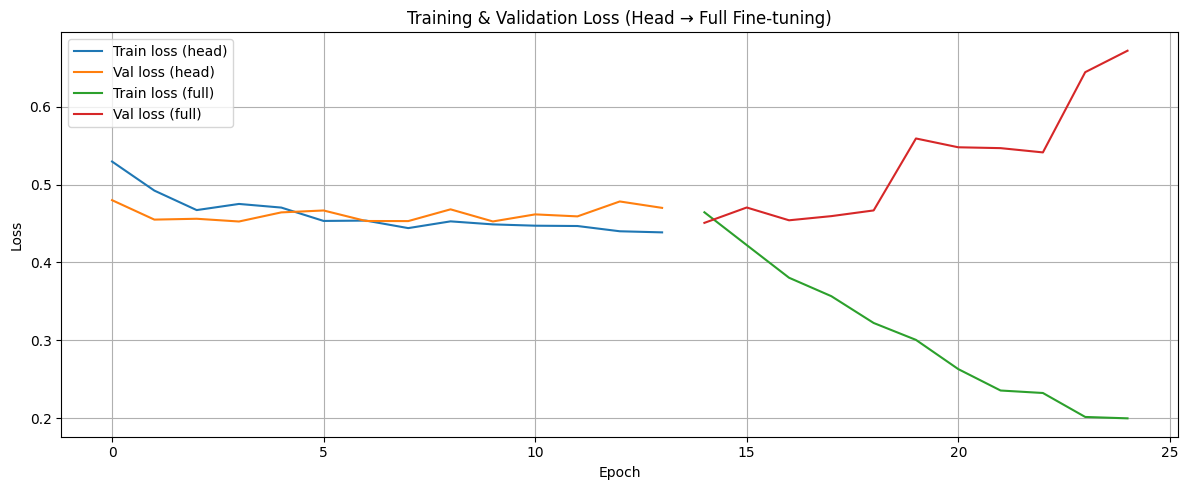

In [10]:
# check if the study metadata is not defined, if not use the last know info:
try:
  study.best_params
except:
  study = None
  #ignore?

if study is None:
  best_lr_head = 0.0007653458354869215
  best_lr_full = 7.054833166231846e-05
  best_batch_size = 32
else:
  best_lr_head = study.best_params["lr_head"]
  best_lr_full = study.best_params["lr_full"]
  best_batch_size = study.best_params["batch_size"]

train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=best_batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
# Initialize model and criterion

model = ResNet50Classifier(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()

# Stage 1
freeze_backbone(model)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=best_lr_head
)

model, history_head = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=1000,
    patience=10,
    save_path=CHECKPOINT_DIR+"/RESNET_1_best_stage1_2_cat.pt"
)

# Stage 2
unfreeze_backbone(model)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr_full
)

model, history_full = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=1000,
    patience=10,
    save_path=CHECKPOINT_DIR+"/RESNET_1_best_stage2_2_cat.pt"
)

import matplotlib.pyplot as plt

# Can't print because I didn't save history before.

plt.figure(figsize=(12, 5))

# Head stage
plt.plot(history_head["train_loss"], label="Train loss (head)")
plt.plot(history_head["val_loss"], label="Val loss (head)")

# Full stage
plt.plot(
    range(len(history_head["train_loss"]),
          len(history_head["train_loss"]) + len(history_full["train_loss"])),
    history_full["train_loss"],
    label="Train loss (full)"
)
plt.plot(
    range(len(history_head["val_loss"]),
          len(history_head["val_loss"]) + len(history_full["val_loss"])),
    history_full["val_loss"],
    label="Val loss (full)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Head → Full Fine-tuning)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2 Model train (Backbone ViT_b_16, 2-stage training: head and full)

### 2.1 Model definition

In [6]:
from VitClassifier_1_defnitions import *

### 2.2 Search for best learning rate with Optuna

In [8]:
import optuna

def objective(trial):
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3, log=True)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Rebuild dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    model = ViTClassifier(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()

    # Stage 1: HEAD only
    freeze_backbone(model)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=lr_head)
    train_model(model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                device,
                epochs=8,
                patience=3,
                save_path=None

    # Stage 2: FULL model
    unfreeze_backbone(model)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_full)
    train_model(model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                device,
                epochs=8,
                patience=3,
                save_path=None

    _, val_acc = evaluate(model, val_loader, criterion, device)
    return val_acc

# Run Optuna
if True:
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=8)  # short for baseline
    print("Best validation accuracy:", study.best_value)
    print("Best hyperparameters:", study.best_params)



[I 2026-02-28 23:35:01,255] A new study created in memory with name: no-name-e705d5a4-9711-4e6e-b7f4-a00665c34e5b


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 113MB/s]


Epoch [1/8] | Train Loss: 0.5516 | Val Loss: 0.4877 | Val Acc: 0.8015
Best model + history saved
Epoch [2/8] | Train Loss: 0.5040 | Val Loss: 0.4620 | Val Acc: 0.7996
Best model + history saved
Epoch [3/8] | Train Loss: 0.4891 | Val Loss: 0.4689 | Val Acc: 0.7920
Epoch [4/8] | Train Loss: 0.4785 | Val Loss: 0.4653 | Val Acc: 0.7863
Epoch [5/8] | Train Loss: 0.4616 | Val Loss: 0.4697 | Val Acc: 0.7863
Early stopping triggered
Epoch [1/8] | Train Loss: 0.5516 | Val Loss: 0.6221 | Val Acc: 0.7137
Best model + history saved
Epoch [2/8] | Train Loss: 0.5941 | Val Loss: 0.5269 | Val Acc: 0.7634
Best model + history saved
Epoch [3/8] | Train Loss: 0.5156 | Val Loss: 0.4990 | Val Acc: 0.7443
Best model + history saved
Epoch [4/8] | Train Loss: 0.4679 | Val Loss: 0.4600 | Val Acc: 0.8130
Best model + history saved
Epoch [5/8] | Train Loss: 0.4517 | Val Loss: 0.4510 | Val Acc: 0.7939
Best model + history saved
Epoch [6/8] | Train Loss: 0.4290 | Val Loss: 0.4609 | Val Acc: 0.7977
Epoch [7/8] | Tr

[I 2026-03-01 00:30:50,183] Trial 0 finished with value: 0.7938931297709924 and parameters: {'lr_head': 0.00018069438488412684, 'lr_full': 2.038620247432877e-05, 'batch_size': 16}. Best is trial 0 with value: 0.7938931297709924.


...

Epoch [1/8] | Train Loss: 0.5489 | Val Loss: 0.4802 | Val Acc: 0.8034
Best model + history saved
Epoch [2/8] | Train Loss: 0.5043 | Val Loss: 0.4699 | Val Acc: 0.7958
Best model + history saved
Epoch [3/8] | Train Loss: 0.4918 | Val Loss: 0.4865 | Val Acc: 0.7863
Epoch [4/8] | Train Loss: 0.4875 | Val Loss: 0.4712 | Val Acc: 0.7977
Epoch [5/8] | Train Loss: 0.4846 | Val Loss: 0.4598 | Val Acc: 0.7996
Best model + history saved
Epoch [6/8] | Train Loss: 0.4803 | Val Loss: 0.4555 | Val Acc: 0.7920
Best model + history saved
Epoch [7/8] | Train Loss: 0.4743 | Val Loss: 0.4591 | Val Acc: 0.7939
Epoch [8/8] | Train Loss: 0.4691 | Val Loss: 0.4539 | Val Acc: 0.7996
Best model + history saved
Epoch [1/8] | Train Loss: 0.5845 | Val Loss: 0.5291 | Val Acc: 0.7233
Best model + history saved
Epoch [2/8] | Train Loss: 0.5192 | Val Loss: 0.4930 | Val Acc: 0.7481
Best model + history saved
Epoch [3/8] | Train Loss: 0.5015 | Val Loss: 0.4995 | Val Acc: 0.7691
Epoch [4/8] | Train Loss: 0.4934 | Val Lo

[I 2026-03-01 05:09:04,222] Trial 7 finished with value: 0.7881679389312977 and parameters: {'lr_head': 0.00013064589782717253, 'lr_full': 4.588795764906525e-05, 'batch_size': 8}. Best is trial 5 with value: 0.8072519083969466.


Best validation accuracy: 0.8072519083969466
Best hyperparameters: {'lr_head': 0.0007727623741481945, 'lr_full': 1.185807916584498e-05, 'batch_size': 8}


NameError: name 'history_head' is not defined

<Figure size 1200x500 with 0 Axes>

Best validation accuracy: 0.8072519083969466
Best hyperparameters: {'lr_head': 0.0007727623741481945, 'lr_full': 1.185807916584498e-05, 'batch_size': 8}

-


### 2.3 Train model with best learning rate found by Optuna

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 191MB/s]


Epoch [1/1000] | Train Loss: 0.5239 | Val Loss: 0.4881 | Val Acc: 0.7901
Best model + history saved
Epoch [2/1000] | Train Loss: 0.5050 | Val Loss: 0.4862 | Val Acc: 0.7977
Best model + history saved
Epoch [3/1000] | Train Loss: 0.4901 | Val Loss: 0.4689 | Val Acc: 0.7996
Best model + history saved
Epoch [4/1000] | Train Loss: 0.4832 | Val Loss: 0.4829 | Val Acc: 0.7977
Epoch [5/1000] | Train Loss: 0.4791 | Val Loss: 0.4698 | Val Acc: 0.7996
Epoch [6/1000] | Train Loss: 0.4769 | Val Loss: 0.4630 | Val Acc: 0.7882
Best model + history saved
Epoch [7/1000] | Train Loss: 0.4760 | Val Loss: 0.4597 | Val Acc: 0.7977
Best model + history saved
Epoch [8/1000] | Train Loss: 0.4759 | Val Loss: 0.4662 | Val Acc: 0.7844
Epoch [9/1000] | Train Loss: 0.4689 | Val Loss: 0.4617 | Val Acc: 0.7767
Epoch [10/1000] | Train Loss: 0.4623 | Val Loss: 0.4702 | Val Acc: 0.7901
Epoch [11/1000] | Train Loss: 0.4664 | Val Loss: 0.4819 | Val Acc: 0.7901
Epoch [12/1000] | Train Loss: 0.4573 | Val Loss: 0.4732 | Va

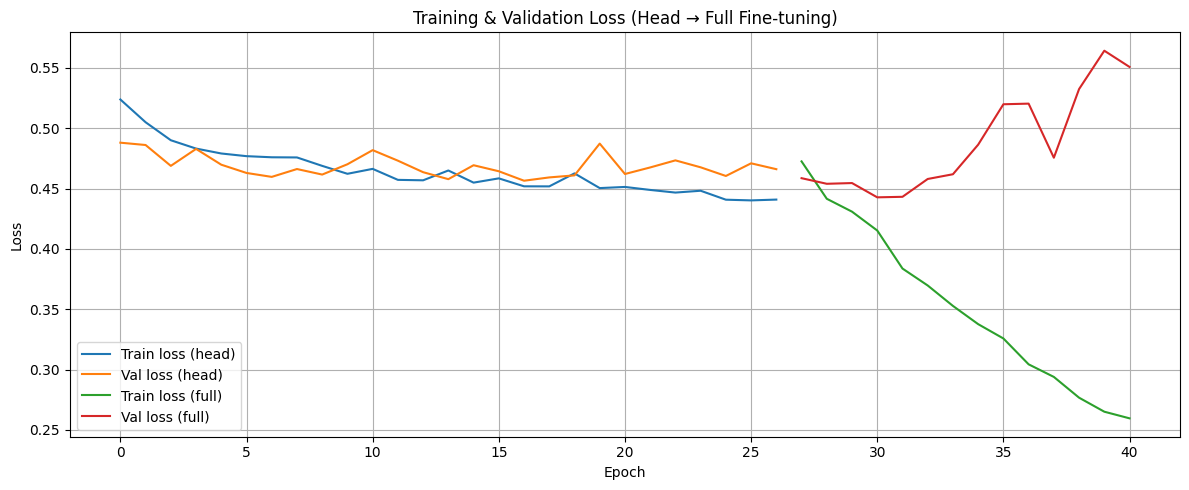

In [7]:
try:
  study.best_params
except:
  study = None
  #ignore?

if study is None:
  best_lr_head = 0.0007727623741481945
  best_lr_full = 1.185807916584498e-05
  best_batch_size = 8
else:
  best_lr_head = study.best_params["lr_head"]
  best_lr_full = study.best_params["lr_full"]
  best_batch_size = study.bese_params["batch_size"]
# Initialize model and criterion

train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=best_batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

model = ViTClassifier(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()

# Stage 1: Train HEAD only
freeze_backbone(model)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=best_lr_head
)

model, history_head = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=1000,   # full training for head
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/vit_1_best_stage1_2_cat.pt"
)

# Stage 2: Train FULL model
unfreeze_backbone(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr_full
)

model, history_full = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=1000,   # full training for full model
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/vit_1_best_stage2_2_cat.pt"
)

import matplotlib.pyplot as plt

# Can't print because I didn't save history before.

plt.figure(figsize=(12, 5))

# Head stage
plt.plot(history_head["train_loss"], label="Train loss (head)")
plt.plot(history_head["val_loss"], label="Val loss (head)")

# Full stage
plt.plot(
    range(len(history_head["train_loss"]),
          len(history_head["train_loss"]) + len(history_full["train_loss"])),
    history_full["train_loss"],
    label="Train loss (full)"
)
plt.plot(
    range(len(history_head["val_loss"]),
          len(history_head["val_loss"]) + len(history_full["val_loss"])),
    history_full["val_loss"],
    label="Val loss (full)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Head → Full Fine-tuning)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. ViT with CLS and Patch Pooling (ViT-CLS+Mean)
Again, two stage training - head and full body. Parameter search for batch size and learnng rate done with Optuna.

** Best hyperparameters: **

$ lr_{head}: 0.00035950484601540223 $

$lr_{full}: 2.271080330783799e-05 $

$ batchsize: 8 $

This work employs a Vision Transformer (ViT-B/16)–based image classification model initialized with ImageNet-1K pretrained weights. The proposed architecture modifies the standard ViT classification head by combining information from both the CLS token and the aggregated patch tokens, aiming to obtain a more robust global image representation for medical image classification.

The backbone of the model is the ViT-B/16 architecture, which splits the input image into non-overlapping 16×16 patches, embeds them into a latent space, and processes the resulting token sequence using a stack of Transformer encoder layers with multi-head self-attention.

### 3.1 Model definition

In [7]:
from VitClassifier_2_definitions import *

### 3.2 Optuna search for learning rate and batch size

In [9]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 11.5 MB/s eta 0:00:00


In [10]:
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def objective(trial):
    # Hyperparameters
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3, log=True)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Rebuild dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # Model
    model = ViTClassifierCLSPool(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()

    # Stage 1: classifier only
    freeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.classifier.parameters(),
        lr=lr_head
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=8,
        patience=3,
        save_path=None
    )

    # Stage 2: full fine-tuning
    unfreeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=8,
        patience=3,
        save_path=None
    )

    _, val_acc = evaluate(model, val_loader, criterion, device)
    return val_acc


if True:
  study = optuna.create_study(direction="maximize")
  study.optimize(objective, n_trials=8)

  print("Best validation accuracy:", study.best_value)
  print("Best hyperparameters:", study.best_params)

[I 2026-03-01 11:23:36,435] A new study created in memory with name: no-name-306e6674-20e2-4499-93c9-35d94ff7627b


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 65.4MB/s]


Epoch [1/8] | Train Loss: 0.5249 | Val Loss: 0.5131 | Val Acc: 0.7786
Epoch [2/8] | Train Loss: 0.4833 | Val Loss: 0.4851 | Val Acc: 0.7748
Epoch [3/8] | Train Loss: 0.4755 | Val Loss: 0.4675 | Val Acc: 0.8053
Epoch [4/8] | Train Loss: 0.4623 | Val Loss: 0.4639 | Val Acc: 0.7844
Epoch [5/8] | Train Loss: 0.4723 | Val Loss: 0.4766 | Val Acc: 0.8130
Epoch [6/8] | Train Loss: 0.4604 | Val Loss: 0.4574 | Val Acc: 0.7958
Epoch [7/8] | Train Loss: 0.4590 | Val Loss: 0.4684 | Val Acc: 0.7882
Epoch [8/8] | Train Loss: 0.4550 | Val Loss: 0.4647 | Val Acc: 0.7748
Epoch [1/8] | Train Loss: 0.6046 | Val Loss: 0.5978 | Val Acc: 0.7137
Epoch [2/8] | Train Loss: 0.6068 | Val Loss: 0.5973 | Val Acc: 0.7137
Epoch [3/8] | Train Loss: 0.5989 | Val Loss: 0.6046 | Val Acc: 0.7137
Epoch [4/8] | Train Loss: 0.6043 | Val Loss: 0.5977 | Val Acc: 0.7137
Epoch [5/8] | Train Loss: 0.5976 | Val Loss: 0.5966 | Val Acc: 0.7137
Epoch [6/8] | Train Loss: 0.5988 | Val Loss: 0.5896 | Val Acc: 0.7137
Epoch [7/8] | Train 

[I 2026-03-01 12:20:09,252] Trial 0 finished with value: 0.7251908396946565 and parameters: {'lr_head': 0.0007095253951607086, 'lr_full': 6.90948231343535e-05, 'batch_size': 8}. Best is trial 0 with value: 0.7251908396946565.


...

Epoch [1/8] | Train Loss: 0.5051 | Val Loss: 0.4660 | Val Acc: 0.7863
Epoch [2/8] | Train Loss: 0.4672 | Val Loss: 0.4883 | Val Acc: 0.7691
Epoch [3/8] | Train Loss: 0.4631 | Val Loss: 0.4621 | Val Acc: 0.7939
Epoch [4/8] | Train Loss: 0.4621 | Val Loss: 0.4596 | Val Acc: 0.7939
Epoch [5/8] | Train Loss: 0.4464 | Val Loss: 0.4557 | Val Acc: 0.7824
Epoch [6/8] | Train Loss: 0.4512 | Val Loss: 0.4639 | Val Acc: 0.7824
Epoch [7/8] | Train Loss: 0.4399 | Val Loss: 0.4854 | Val Acc: 0.7748
Epoch [8/8] | Train Loss: 0.4391 | Val Loss: 0.4497 | Val Acc: 0.8034
Epoch [1/8] | Train Loss: 0.4399 | Val Loss: 0.4724 | Val Acc: 0.7901
Epoch [2/8] | Train Loss: 0.4080 | Val Loss: 0.4443 | Val Acc: 0.8053
Epoch [3/8] | Train Loss: 0.3763 | Val Loss: 0.4663 | Val Acc: 0.7996
Epoch [4/8] | Train Loss: 0.3473 | Val Loss: 0.5296 | Val Acc: 0.7595
Epoch [5/8] | Train Loss: 0.3182 | Val Loss: 0.4831 | Val Acc: 0.7901
Early stopping triggered


[I 2026-03-01 15:47:37,868] Trial 6 finished with value: 0.8053435114503816 and parameters: {'lr_head': 0.0005735450729112735, 'lr_full': 1.2273660799854682e-05, 'batch_size': 32}. Best is trial 2 with value: 0.8053435114503816.


Epoch [1/8] | Train Loss: 0.4924 | Val Loss: 0.4641 | Val Acc: 0.7863
Epoch [2/8] | Train Loss: 0.4686 | Val Loss: 0.4824 | Val Acc: 0.7920
Epoch [3/8] | Train Loss: 0.4693 | Val Loss: 0.4615 | Val Acc: 0.7996
Epoch [4/8] | Train Loss: 0.4541 | Val Loss: 0.4512 | Val Acc: 0.8034
Epoch [5/8] | Train Loss: 0.4490 | Val Loss: 0.4573 | Val Acc: 0.7882
Epoch [6/8] | Train Loss: 0.4384 | Val Loss: 0.4614 | Val Acc: 0.7939
Epoch [7/8] | Train Loss: 0.4396 | Val Loss: 0.4601 | Val Acc: 0.7805
Early stopping triggered
Epoch [1/8] | Train Loss: 0.4436 | Val Loss: 0.4481 | Val Acc: 0.7977
Epoch [2/8] | Train Loss: 0.4104 | Val Loss: 0.4442 | Val Acc: 0.8073
Epoch [3/8] | Train Loss: 0.3844 | Val Loss: 0.4713 | Val Acc: 0.7958
Epoch [4/8] | Train Loss: 0.3581 | Val Loss: 0.4436 | Val Acc: 0.8111
Epoch [5/8] | Train Loss: 0.3204 | Val Loss: 0.5033 | Val Acc: 0.7805
Epoch [6/8] | Train Loss: 0.2899 | Val Loss: 0.5364 | Val Acc: 0.7748
Epoch [7/8] | Train Loss: 0.2496 | Val Loss: 0.5996 | Val Acc: 0.

[I 2026-03-01 16:16:43,910] Trial 7 finished with value: 0.8110687022900763 and parameters: {'lr_head': 0.0002984473868374973, 'lr_full': 1.5492057892693426e-05, 'batch_size': 32}. Best is trial 7 with value: 0.8110687022900763.


Best validation accuracy: 0.8110687022900763
Best hyperparameters: {'lr_head': 0.0002984473868374973, 'lr_full': 1.5492057892693426e-05, 'batch_size': 32}


Best:Best validation accuracy: 0.8110687022900763
Best hyperparameters: {'lr_head': 0.0002984473868374973, 'lr_full': 1.5492057892693426e-05, 'batch_size': 32}




### 3.3 Train model with best parameters found by optuna

Epoch [1/1000] | Train Loss: 0.4909 | Val Loss: 0.4774 | Val Acc: 0.7901
Best model + history saved
Epoch [2/1000] | Train Loss: 0.4727 | Val Loss: 0.4573 | Val Acc: 0.7920
Best model + history saved
Epoch [3/1000] | Train Loss: 0.4563 | Val Loss: 0.4941 | Val Acc: 0.7691
Epoch [4/1000] | Train Loss: 0.4532 | Val Loss: 0.4659 | Val Acc: 0.7729
Epoch [5/1000] | Train Loss: 0.4394 | Val Loss: 0.4685 | Val Acc: 0.7805
Epoch [6/1000] | Train Loss: 0.4382 | Val Loss: 0.4515 | Val Acc: 0.7901
Best model + history saved
Epoch [7/1000] | Train Loss: 0.4347 | Val Loss: 0.4589 | Val Acc: 0.7977
Epoch [8/1000] | Train Loss: 0.4381 | Val Loss: 0.4546 | Val Acc: 0.7920
Epoch [9/1000] | Train Loss: 0.4352 | Val Loss: 0.4606 | Val Acc: 0.7920
Epoch [10/1000] | Train Loss: 0.4201 | Val Loss: 0.4930 | Val Acc: 0.7729
Epoch [11/1000] | Train Loss: 0.4259 | Val Loss: 0.4567 | Val Acc: 0.7920
Epoch [12/1000] | Train Loss: 0.4256 | Val Loss: 0.4635 | Val Acc: 0.7939
Epoch [13/1000] | Train Loss: 0.4186 | V

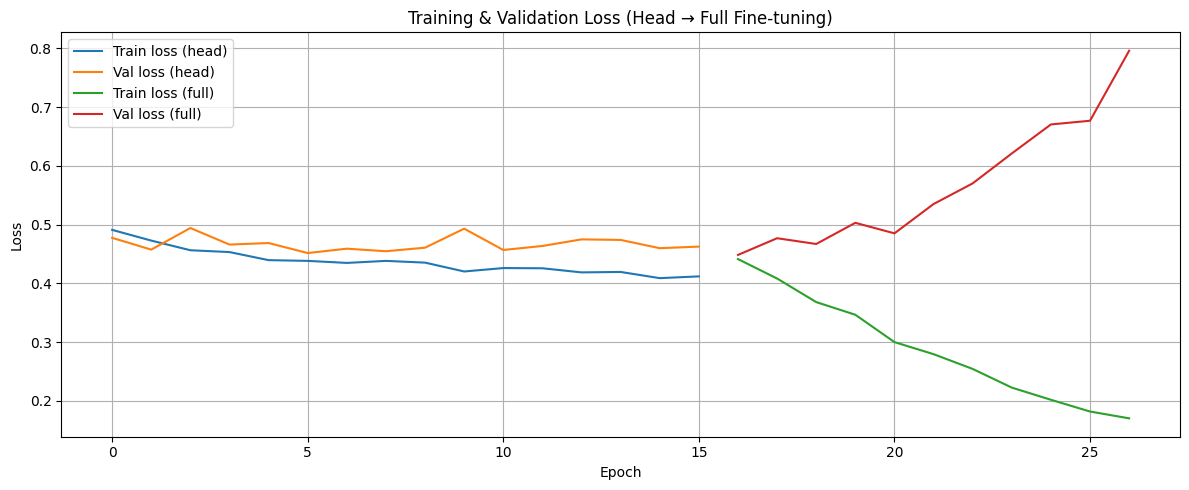

In [11]:
try:
  study.best_params
except:
  study = None
  #ignore?

if study is None:
  best_lr_head = 0.0002984473868374973
  best_lr_full = 1.5492057892693426e-05
  best_batch_size = 32
else:
  best_lr_head = study.best_params["lr_head"]
  best_lr_full = study.best_params["lr_full"]
  best_batch_size = study.best_params["batch_size"]


train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=best_batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

model = ViTClassifierCLSPool(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()

freeze_backbone(model)

optimizer = torch.optim.AdamW(
      model.classifier.parameters(),
      lr=best_lr_head
)

model, history_head = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"vit_2_stage1_best_2_cat.pt"
)

# do retrain the second stage, because it failed the first time...
  # model = ViTClassifierCLSPool(num_classes=11).to(device)
  # criterion = nn.CrossEntropyLoss()

  # model.load_state_dict(
  #   torch.load("vit_2_stage2_best.pt", map_location=device))

  # checkpoint = torch.load("vit_2_stage2_best.pt", map_location=device)

  # model.load_state_dict(checkpoint["model_state"])
  # history = checkpoint["history"]

  # print("Resume from best epoch:", checkpoint["epoch"])
  # print("Resume from Best val loss:", checkpoint["best_val_loss"])


unfreeze_backbone(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr_full
)

model, history_full = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"vit_2_stage2_best_2_cat.pt"
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Head stage
plt.plot(history_head["train_loss"], label="Train loss (head)")
plt.plot(history_head["val_loss"], label="Val loss (head)")

# Full stage
plt.plot(
    range(len(history_head["train_loss"]),
          len(history_head["train_loss"]) + len(history_full["train_loss"])),
    history_full["train_loss"],
    label="Train loss (full)"
)
plt.plot(
    range(len(history_head["val_loss"]),
          len(history_head["val_loss"]) + len(history_full["val_loss"])),
    history_full["val_loss"],
    label="Val loss (full)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Head → Full Fine-tuning)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



### 4. ViT with deep head


### 4.1 model function definitions:

In [ ]:
from VitClassifier_3_definitions import *

### 4.2 Find best parameters with Optuna

In [7]:
# install optuna if not before:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 11.0 MB/s eta 0:00:00


In [9]:
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def objective(trial):
    # Hyperparameters
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3, log=True)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Rebuild dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # Model
    model = ViTClassifierDeepHead(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()

    # Stage 1: classifier only
    freeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.classifier.parameters(),
        lr=lr_head
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=8,
        patience=3,
        save_path=None
    )

    # Stage 2: full fine-tuning
    unfreeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=8,
        patience=3,
        save_path=None
    )

    _, val_acc = evaluate(model, val_loader, criterion, device)
    return val_acc


if True:
  study = optuna.create_study(direction="maximize")
  study.optimize(objective, n_trials=8)

  print("Best validation accuracy:", study.best_value)
  print("Best hyperparameters:", study.best_params)

[I 2026-03-01 21:02:51,640] A new study created in memory with name: no-name-02b83262-37b2-4c98-ad4c-be0a074d2b45


Epoch [1/8] | Train Loss: 0.5038 | Val Loss: 0.4653 | Val Acc: 0.7824
Epoch [2/8] | Train Loss: 0.4786 | Val Loss: 0.4857 | Val Acc: 0.7901
Epoch [3/8] | Train Loss: 0.4639 | Val Loss: 0.4605 | Val Acc: 0.7805
Epoch [4/8] | Train Loss: 0.4523 | Val Loss: 0.4848 | Val Acc: 0.7901
Epoch [5/8] | Train Loss: 0.4491 | Val Loss: 0.4607 | Val Acc: 0.7958
Epoch [6/8] | Train Loss: 0.4447 | Val Loss: 0.4765 | Val Acc: 0.7844
Early stopping triggered
Epoch [1/8] | Train Loss: 0.4391 | Val Loss: 0.4679 | Val Acc: 0.7901
Epoch [2/8] | Train Loss: 0.4061 | Val Loss: 0.4421 | Val Acc: 0.8111
Epoch [3/8] | Train Loss: 0.3871 | Val Loss: 0.4757 | Val Acc: 0.7939
Epoch [4/8] | Train Loss: 0.3532 | Val Loss: 0.4519 | Val Acc: 0.8111
Epoch [5/8] | Train Loss: 0.3405 | Val Loss: 0.4721 | Val Acc: 0.7958
Early stopping triggered


[I 2026-03-01 21:35:07,455] Trial 0 finished with value: 0.8110687022900763 and parameters: {'lr_head': 0.0004989213115745705, 'lr_full': 1.077700404432833e-05, 'batch_size': 32}. Best is trial 0 with value: 0.8110687022900763.


Epoch [1/8] | Train Loss: 0.5109 | Val Loss: 0.4752 | Val Acc: 0.7786
Epoch [2/8] | Train Loss: 0.4694 | Val Loss: 0.4676 | Val Acc: 0.7805
Epoch [3/8] | Train Loss: 0.4643 | Val Loss: 0.4656 | Val Acc: 0.7824
Epoch [4/8] | Train Loss: 0.4585 | Val Loss: 0.4681 | Val Acc: 0.7958
Epoch [5/8] | Train Loss: 0.4469 | Val Loss: 0.4596 | Val Acc: 0.7805
Epoch [6/8] | Train Loss: 0.4441 | Val Loss: 0.4609 | Val Acc: 0.7901
Epoch [7/8] | Train Loss: 0.4316 | Val Loss: 0.4719 | Val Acc: 0.7901
Epoch [8/8] | Train Loss: 0.4351 | Val Loss: 0.4621 | Val Acc: 0.7824
Early stopping triggered
Epoch [1/8] | Train Loss: 0.4834 | Val Loss: 0.4605 | Val Acc: 0.8073
Epoch [2/8] | Train Loss: 0.4516 | Val Loss: 0.5111 | Val Acc: 0.7615
Epoch [3/8] | Train Loss: 0.4327 | Val Loss: 0.4707 | Val Acc: 0.7748
Epoch [4/8] | Train Loss: 0.4204 | Val Loss: 0.4771 | Val Acc: 0.7710
Early stopping triggered


[I 2026-03-01 22:09:39,254] Trial 1 finished with value: 0.8072519083969466 and parameters: {'lr_head': 0.00012534070318586846, 'lr_full': 4.623587202576971e-05, 'batch_size': 16}. Best is trial 0 with value: 0.8110687022900763.


...

Epoch [1/8] | Train Loss: 0.5128 | Val Loss: 0.4713 | Val Acc: 0.7863
Epoch [2/8] | Train Loss: 0.4752 | Val Loss: 0.4721 | Val Acc: 0.7844
Epoch [3/8] | Train Loss: 0.4603 | Val Loss: 0.4618 | Val Acc: 0.7977
Epoch [4/8] | Train Loss: 0.4496 | Val Loss: 0.4778 | Val Acc: 0.7920
Epoch [5/8] | Train Loss: 0.4458 | Val Loss: 0.4602 | Val Acc: 0.7901
Epoch [6/8] | Train Loss: 0.4420 | Val Loss: 0.4942 | Val Acc: 0.7710
Epoch [7/8] | Train Loss: 0.4446 | Val Loss: 0.4729 | Val Acc: 0.7939
Epoch [8/8] | Train Loss: 0.4300 | Val Loss: 0.4880 | Val Acc: 0.7863
Early stopping triggered
Epoch [1/8] | Train Loss: 0.4921 | Val Loss: 0.4850 | Val Acc: 0.7672
Epoch [2/8] | Train Loss: 0.4562 | Val Loss: 0.5061 | Val Acc: 0.7538
Epoch [3/8] | Train Loss: 0.4435 | Val Loss: 0.5038 | Val Acc: 0.7901
Epoch [4/8] | Train Loss: 0.4325 | Val Loss: 0.4851 | Val Acc: 0.7901
Early stopping triggered


[I 2026-03-02 00:42:24,693] Trial 6 finished with value: 0.767175572519084 and parameters: {'lr_head': 0.00024948835772375824, 'lr_full': 7.686548742940674e-05, 'batch_size': 32}. Best is trial 0 with value: 0.8110687022900763.


Epoch [1/8] | Train Loss: 0.5093 | Val Loss: 0.4731 | Val Acc: 0.7844
Epoch [2/8] | Train Loss: 0.4784 | Val Loss: 0.4677 | Val Acc: 0.7805
Epoch [3/8] | Train Loss: 0.4587 | Val Loss: 0.4688 | Val Acc: 0.7844
Epoch [4/8] | Train Loss: 0.4569 | Val Loss: 0.4791 | Val Acc: 0.8092
Epoch [5/8] | Train Loss: 0.4562 | Val Loss: 0.4684 | Val Acc: 0.7977
Early stopping triggered
Epoch [1/8] | Train Loss: 0.4729 | Val Loss: 0.4704 | Val Acc: 0.7844
Epoch [2/8] | Train Loss: 0.4568 | Val Loss: 0.4493 | Val Acc: 0.8149
Epoch [3/8] | Train Loss: 0.4247 | Val Loss: 0.5049 | Val Acc: 0.7443
Epoch [4/8] | Train Loss: 0.4048 | Val Loss: 0.4689 | Val Acc: 0.8015
Epoch [5/8] | Train Loss: 0.3819 | Val Loss: 0.4839 | Val Acc: 0.7748
Early stopping triggered


[I 2026-03-02 01:11:30,308] Trial 7 finished with value: 0.8148854961832062 and parameters: {'lr_head': 0.0002960880749415009, 'lr_full': 4.315046656586249e-05, 'batch_size': 16}. Best is trial 7 with value: 0.8148854961832062.


Best validation accuracy: 0.8148854961832062
Best hyperparameters: {'lr_head': 0.0002960880749415009, 'lr_full': 4.315046656586249e-05, 'batch_size': 16}


Best parameters:
Best validation accuracy: 0.8148854961832062
Best hyperparameters: {'lr_head': 0.0002960880749415009, 'lr_full': 4.315046656586249e-05, 'batch_size': 16}



### 4.3 Train model with the best optuna parameters

Epoch [1/1000] | Train Loss: 0.5035 | Val Loss: 0.4674 | Val Acc: 0.7882
Best model + history saved
Epoch [2/1000] | Train Loss: 0.4753 | Val Loss: 0.4902 | Val Acc: 0.7863
Epoch [3/1000] | Train Loss: 0.4624 | Val Loss: 0.4814 | Val Acc: 0.7863
Epoch [4/1000] | Train Loss: 0.4540 | Val Loss: 0.4925 | Val Acc: 0.7786
Epoch [5/1000] | Train Loss: 0.4489 | Val Loss: 0.4627 | Val Acc: 0.7824
Best model + history saved
Epoch [6/1000] | Train Loss: 0.4432 | Val Loss: 0.4881 | Val Acc: 0.7920
Epoch [7/1000] | Train Loss: 0.4402 | Val Loss: 0.4710 | Val Acc: 0.7920
Epoch [8/1000] | Train Loss: 0.4357 | Val Loss: 0.4674 | Val Acc: 0.7863
Epoch [9/1000] | Train Loss: 0.4303 | Val Loss: 0.4650 | Val Acc: 0.7939
Epoch [10/1000] | Train Loss: 0.4247 | Val Loss: 0.4710 | Val Acc: 0.7805
Epoch [11/1000] | Train Loss: 0.4229 | Val Loss: 0.5086 | Val Acc: 0.7920
Epoch [12/1000] | Train Loss: 0.4186 | Val Loss: 0.4742 | Val Acc: 0.7863
Epoch [13/1000] | Train Loss: 0.4149 | Val Loss: 0.4714 | Val Acc: 

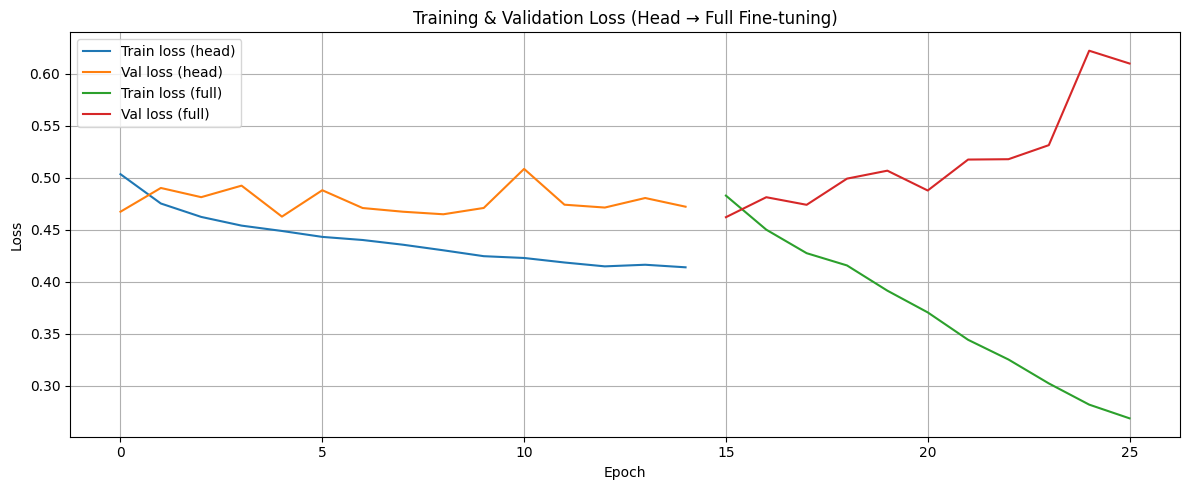

In [10]:
try:
  study.best_params
except:
  study = None
  #ignore?

if study is None:
  best_lr_head = 0.0002960880749415009
  best_lr_full = 4.315046656586249e-05
  best_batch_size = 16
else:
  best_lr_head = study.best_params["lr_head"]
  best_lr_full = study.best_params["lr_full"]
  best_batch_size = study.best_params["batch_size"]


train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=best_batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

model = ViTClassifierDeepHead(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()

freeze_backbone(model)

optimizer = torch.optim.AdamW(
      model.classifier.parameters(),
      lr=best_lr_head
)

model, history_head = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"vit_3_stage1_best_2_cat.pt"
)

# do retrain the second stage, because it failed the first time...
  # model = ViTClassifierCLSPool(num_classes=11).to(device)
  # criterion = nn.CrossEntropyLoss()

  # model.load_state_dict(
  #   torch.load("vit_2_stage2_best.pt", map_location=device))

  # checkpoint = torch.load("vit_2_stage2_best.pt", map_location=device)

  # model.load_state_dict(checkpoint["model_state"])
  # history = checkpoint["history"]

  # print("Resume from best epoch:", checkpoint["epoch"])
  # print("Resume from Best val loss:", checkpoint["best_val_loss"])


unfreeze_backbone(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr_full
)

model, history_full = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"vit_3_stage2_best_2_cat.pt"
)

import matplotlib.pyplot as plt

# Can't print because I didn't save history before.

plt.figure(figsize=(12, 5))

# Head stage
plt.plot(history_head["train_loss"], label="Train loss (head)")
plt.plot(history_head["val_loss"], label="Val loss (head)")

# Full stage
plt.plot(
    range(len(history_head["train_loss"]),
          len(history_head["train_loss"]) + len(history_full["train_loss"])),
    history_full["train_loss"],
    label="Train loss (full)"
)
plt.plot(
    range(len(history_head["val_loss"]),
          len(history_head["val_loss"]) + len(history_full["val_loss"])),
    history_full["val_loss"],
    label="Val loss (full)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Head → Full Fine-tuning)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



## 5. ResNet 18 first try


In [6]:
from ResNet18_1_definitions import *

In [7]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.9 MB/s eta 0:00:00


In [8]:
import optuna
import torch.nn as nn

def objective(trial):
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Rebuild dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    model = ResNet18Classifier(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()

    # STAGE 1: HEAD ONLY
    freeze_backbone(model)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=8,   # short for Optuna
        patience=3,
        save_path=None
    )

    # STAGE 2: FULL MODEL
    unfreeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=8,   # also short
        patience=3,
        save_path=None
    )

    # Final evaluation
    _, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    return val_acc

############# Run the study:
if True:
  study = optuna.create_study(
      direction="maximize"
  )

  study.optimize(
      objective,
      n_trials=8,
      timeout=None          # optional
  )

  print("Best validation accuracy:", study.best_value)
  print("Best hyperparameters:", study.best_params)

[I 2026-03-02 22:28:43,505] A new study created in memory with name: no-name-7b1e72fc-c14f-466a-a612-98ec52297752


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 107MB/s]


Epoch [1/8] | Train Loss: 0.6589 | Val Loss: 0.5133 | Val Acc: 0.7882
Epoch [2/8] | Train Loss: 0.5310 | Val Loss: 0.4787 | Val Acc: 0.7824
Epoch [3/8] | Train Loss: 0.5061 | Val Loss: 0.4783 | Val Acc: 0.7958
Epoch [4/8] | Train Loss: 0.4943 | Val Loss: 0.4687 | Val Acc: 0.7901
Epoch [5/8] | Train Loss: 0.4853 | Val Loss: 0.4637 | Val Acc: 0.7901
Epoch [6/8] | Train Loss: 0.4875 | Val Loss: 0.4591 | Val Acc: 0.7863
Epoch [7/8] | Train Loss: 0.4771 | Val Loss: 0.4575 | Val Acc: 0.7824
Epoch [8/8] | Train Loss: 0.4676 | Val Loss: 0.4600 | Val Acc: 0.7901
Epoch [1/8] | Train Loss: 0.4812 | Val Loss: 0.4301 | Val Acc: 0.8092
Epoch [2/8] | Train Loss: 0.4308 | Val Loss: 0.4641 | Val Acc: 0.8015
Epoch [3/8] | Train Loss: 0.3932 | Val Loss: 0.4553 | Val Acc: 0.8149
Epoch [4/8] | Train Loss: 0.3633 | Val Loss: 0.4572 | Val Acc: 0.8149
Early stopping triggered


[I 2026-03-02 22:46:38,719] Trial 0 finished with value: 0.8091603053435115 and parameters: {'lr_head': 0.00017128770083720156, 'lr_full': 7.637867119664237e-05, 'batch_size': 32}. Best is trial 0 with value: 0.8091603053435115.


...

Epoch [1/8] | Train Loss: 0.5346 | Val Loss: 0.4621 | Val Acc: 0.8015
Epoch [2/8] | Train Loss: 0.4919 | Val Loss: 0.4566 | Val Acc: 0.7996
Epoch [3/8] | Train Loss: 0.4791 | Val Loss: 0.4537 | Val Acc: 0.7882
Epoch [4/8] | Train Loss: 0.4706 | Val Loss: 0.4613 | Val Acc: 0.7958
Epoch [5/8] | Train Loss: 0.4578 | Val Loss: 0.4572 | Val Acc: 0.8015
Epoch [6/8] | Train Loss: 0.4618 | Val Loss: 0.4531 | Val Acc: 0.7901
Epoch [7/8] | Train Loss: 0.4632 | Val Loss: 0.4598 | Val Acc: 0.7844
Epoch [8/8] | Train Loss: 0.4602 | Val Loss: 0.4622 | Val Acc: 0.7844
Epoch [1/8] | Train Loss: 0.4601 | Val Loss: 0.4420 | Val Acc: 0.8015
Epoch [2/8] | Train Loss: 0.4058 | Val Loss: 0.4685 | Val Acc: 0.7977
Epoch [3/8] | Train Loss: 0.3727 | Val Loss: 0.4649 | Val Acc: 0.8053
Epoch [4/8] | Train Loss: 0.3269 | Val Loss: 0.5087 | Val Acc: 0.8015
Early stopping triggered


[I 2026-03-02 23:15:58,413] Trial 6 finished with value: 0.8015267175572519 and parameters: {'lr_head': 0.0007108483726949946, 'lr_full': 7.15066079115038e-05, 'batch_size': 32}. Best is trial 5 with value: 0.8129770992366412.


Epoch [1/8] | Train Loss: 0.5347 | Val Loss: 0.4478 | Val Acc: 0.8034
Epoch [2/8] | Train Loss: 0.4953 | Val Loss: 0.4532 | Val Acc: 0.7996
Epoch [3/8] | Train Loss: 0.4931 | Val Loss: 0.4568 | Val Acc: 0.7996
Epoch [4/8] | Train Loss: 0.4822 | Val Loss: 0.4606 | Val Acc: 0.7958
Early stopping triggered
Epoch [1/8] | Train Loss: 0.5007 | Val Loss: 0.4622 | Val Acc: 0.7958
Epoch [2/8] | Train Loss: 0.4469 | Val Loss: 0.4479 | Val Acc: 0.7996
Epoch [3/8] | Train Loss: 0.4245 | Val Loss: 0.4469 | Val Acc: 0.7958
Epoch [4/8] | Train Loss: 0.3997 | Val Loss: 0.4562 | Val Acc: 0.7977
Epoch [5/8] | Train Loss: 0.3761 | Val Loss: 0.4738 | Val Acc: 0.7901
Epoch [6/8] | Train Loss: 0.3346 | Val Loss: 0.5537 | Val Acc: 0.7615
Early stopping triggered


[I 2026-03-02 23:20:00,611] Trial 7 finished with value: 0.7958015267175572 and parameters: {'lr_head': 0.0005988689149986328, 'lr_full': 5.856451129103902e-05, 'batch_size': 16}. Best is trial 5 with value: 0.8129770992366412.


Best validation accuracy: 0.8129770992366412
Best hyperparameters: {'lr_head': 0.00047144579727403805, 'lr_full': 2.9265045361105292e-05, 'batch_size': 16}


0.8129770992366412
Best hyperparameters: {'lr_head': 0.00047144579727403805, 'lr_full': 2.9265045361105292e-05, 'batch_size': 16}


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Epoch [1/1000] | Train Loss: 0.5437 | Val Loss: 0.4722 | Val Acc: 0.7920
Best model + history saved
Epoch [2/1000] | Train Loss: 0.5039 | Val Loss: 0.4657 | Val Acc: 0.7977
Best model + history saved
Epoch [3/1000] | Train Loss: 0.4873 | Val Loss: 0.4621 | Val Acc: 0.7863
Best model + history saved
Epoch [4/1000] | Train Loss: 0.4811 | Val Loss: 0.4627 | Val Acc: 0.7958
Epoch [5/1000] | Train Loss: 0.4747 | Val Loss: 0.4715 | Val Acc: 0.7863
Epoch [6/1000] | Train Loss: 0.4727 | Val Loss: 0.4588 | Val Acc: 0.7977
Best model + history saved
Epoch [7/1000] | Train Loss: 0.4653 | Val Loss: 0.4680 | Val Acc: 0.7824
Epoch [8/1000] | Train Loss: 0.4612 | Val Loss: 0.4662 | Val Acc: 0.7939
Epoch [9/1000] | Train Loss: 0.4566 | Val Loss: 0.4677 | Val Acc: 0.7882
Epoch [10/1000] | Train Loss: 0.4574 | Val Loss: 0.4679 | Val Acc: 0.7920
Epoch [11/1000] | Train Loss: 0.4564 | Val Loss: 0.4592 | Val Acc: 0.8034
Epoch [12/1000] | Train Loss: 0.4545 | Val Loss: 0.4628 | Val Acc: 0.7786
Epoch [13/100

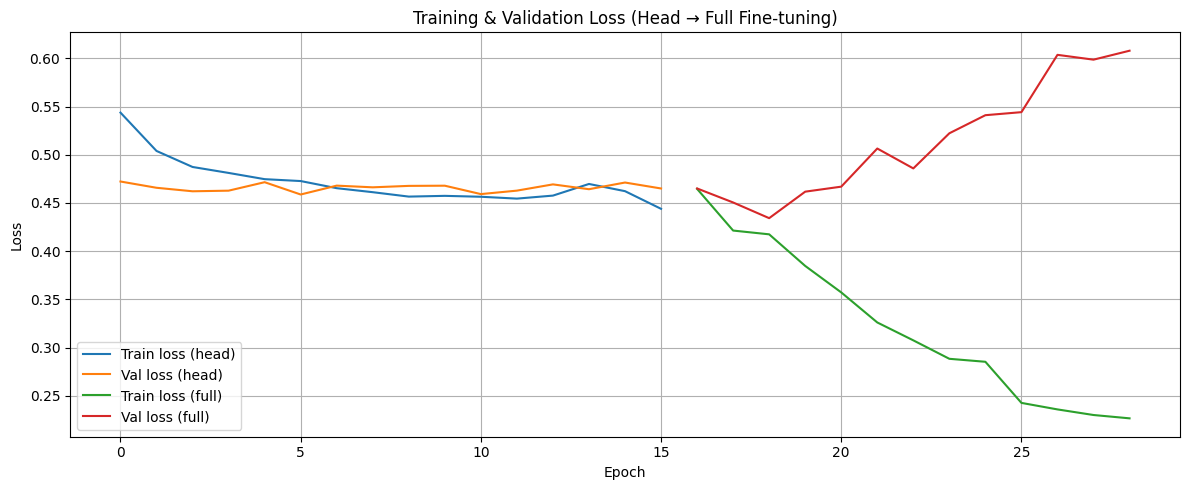

In [7]:
try:
  study.best_params
except:
  study = None
  #ignore?

if study is None:
  best_lr_head = 0.00047144579727403805
  best_lr_full = 2.9265045361105292e-05
  best_batch_size = 16
else:
  best_lr_head = study.best_params["lr_head"]
  best_lr_full = study.best_params["lr_full"]
  best_batch_size = study.best_params["batch_size"]


train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=best_batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

model = ResNet18Classifier(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()

freeze_backbone(model)

optimizer = torch.optim.AdamW(
      model.head.parameters(),
      lr=best_lr_head
)

model, history_head = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"Resnet_2_stage1_best_2_cat.pt"
)

# do retrain the second stage, because it failed the first time...
  # model = ViTClassifierCLSPool(num_classes=11).to(device)
  # criterion = nn.CrossEntropyLoss()

  # model.load_state_dict(
  #   torch.load("vit_2_stage2_best.pt", map_location=device))

  # checkpoint = torch.load("vit_2_stage2_best.pt", map_location=device)

  # model.load_state_dict(checkpoint["model_state"])
  # history = checkpoint["history"]

  # print("Resume from best epoch:", checkpoint["epoch"])
  # print("Resume from Best val loss:", checkpoint["best_val_loss"])


unfreeze_backbone(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr_full
)

model, history_full = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"Resnet_2_stage2_best_2_cat.pt"
)

import matplotlib.pyplot as plt

# Can't print because I didn't save history before.

plt.figure(figsize=(12, 5))

# Head stage
plt.plot(history_head["train_loss"], label="Train loss (head)")
plt.plot(history_head["val_loss"], label="Val loss (head)")

# Full stage
plt.plot(
    range(len(history_head["train_loss"]),
          len(history_head["train_loss"]) + len(history_full["train_loss"])),
    history_full["train_loss"],
    label="Train loss (full)"
)
plt.plot(
    range(len(history_head["val_loss"]),
          len(history_head["val_loss"]) + len(history_full["val_loss"])),
    history_full["val_loss"],
    label="Val loss (full)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Head → Full Fine-tuning)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Hopefully it's oK :D:D:D